In [26]:
import keras
import numpy as np
from keras.src.ops import expand_dims

keras.layers.Dense(512, activation="relu") # relu is an activation function performed on 512 outputs

<Dense name=dense_2, built=False>

### How do these layers work?
1. Linear step: z = Wb + b <br>
``` python
keras.layers.Dense(512..
```
multiply by weights W and add the bias b <br>
2. Activation step: a = activation(z) <br>
``` python
...activation="relu")
```
apply the activation function <br>

### Rectified Linear Unit (Relu)
Rectified Linear Unit (relu) = performing max(0, x) where x is an output in a tensor.
<br> e.g. ```[3, -2, 1, -5]``` becomes ```[3, 0, 1, 0]``` <br>
<br>We use relu because it allows to view non-linearity (curves) which is more powerful than just doing linear -> linear -> linear we are now doing linear -> relu -> linear -> relu. We combine linear layers with non-linear activations so the network can produce curved functions overall. <br>

#### Example of add and relu element-wise operations using numpy

In [27]:
x = 4
y = 5
np.array([1, 4, 2, 1])

z = x + y  # element-wise addition
np.maximum(z, 0.0)  # element-wise relu

np.float64(9.0)

### Broadcasting <br>
Useful when two tensors differ in shape e.g. trying to add 2-rank with a 3-rank. Then we use broadcasting:<br>
The smaller tensor will be broadcast to match the larger tensor with two steps:<br>
1. Broadcast axes are added to the smaller tensor to match the ```ndim``` of the larger tensor.
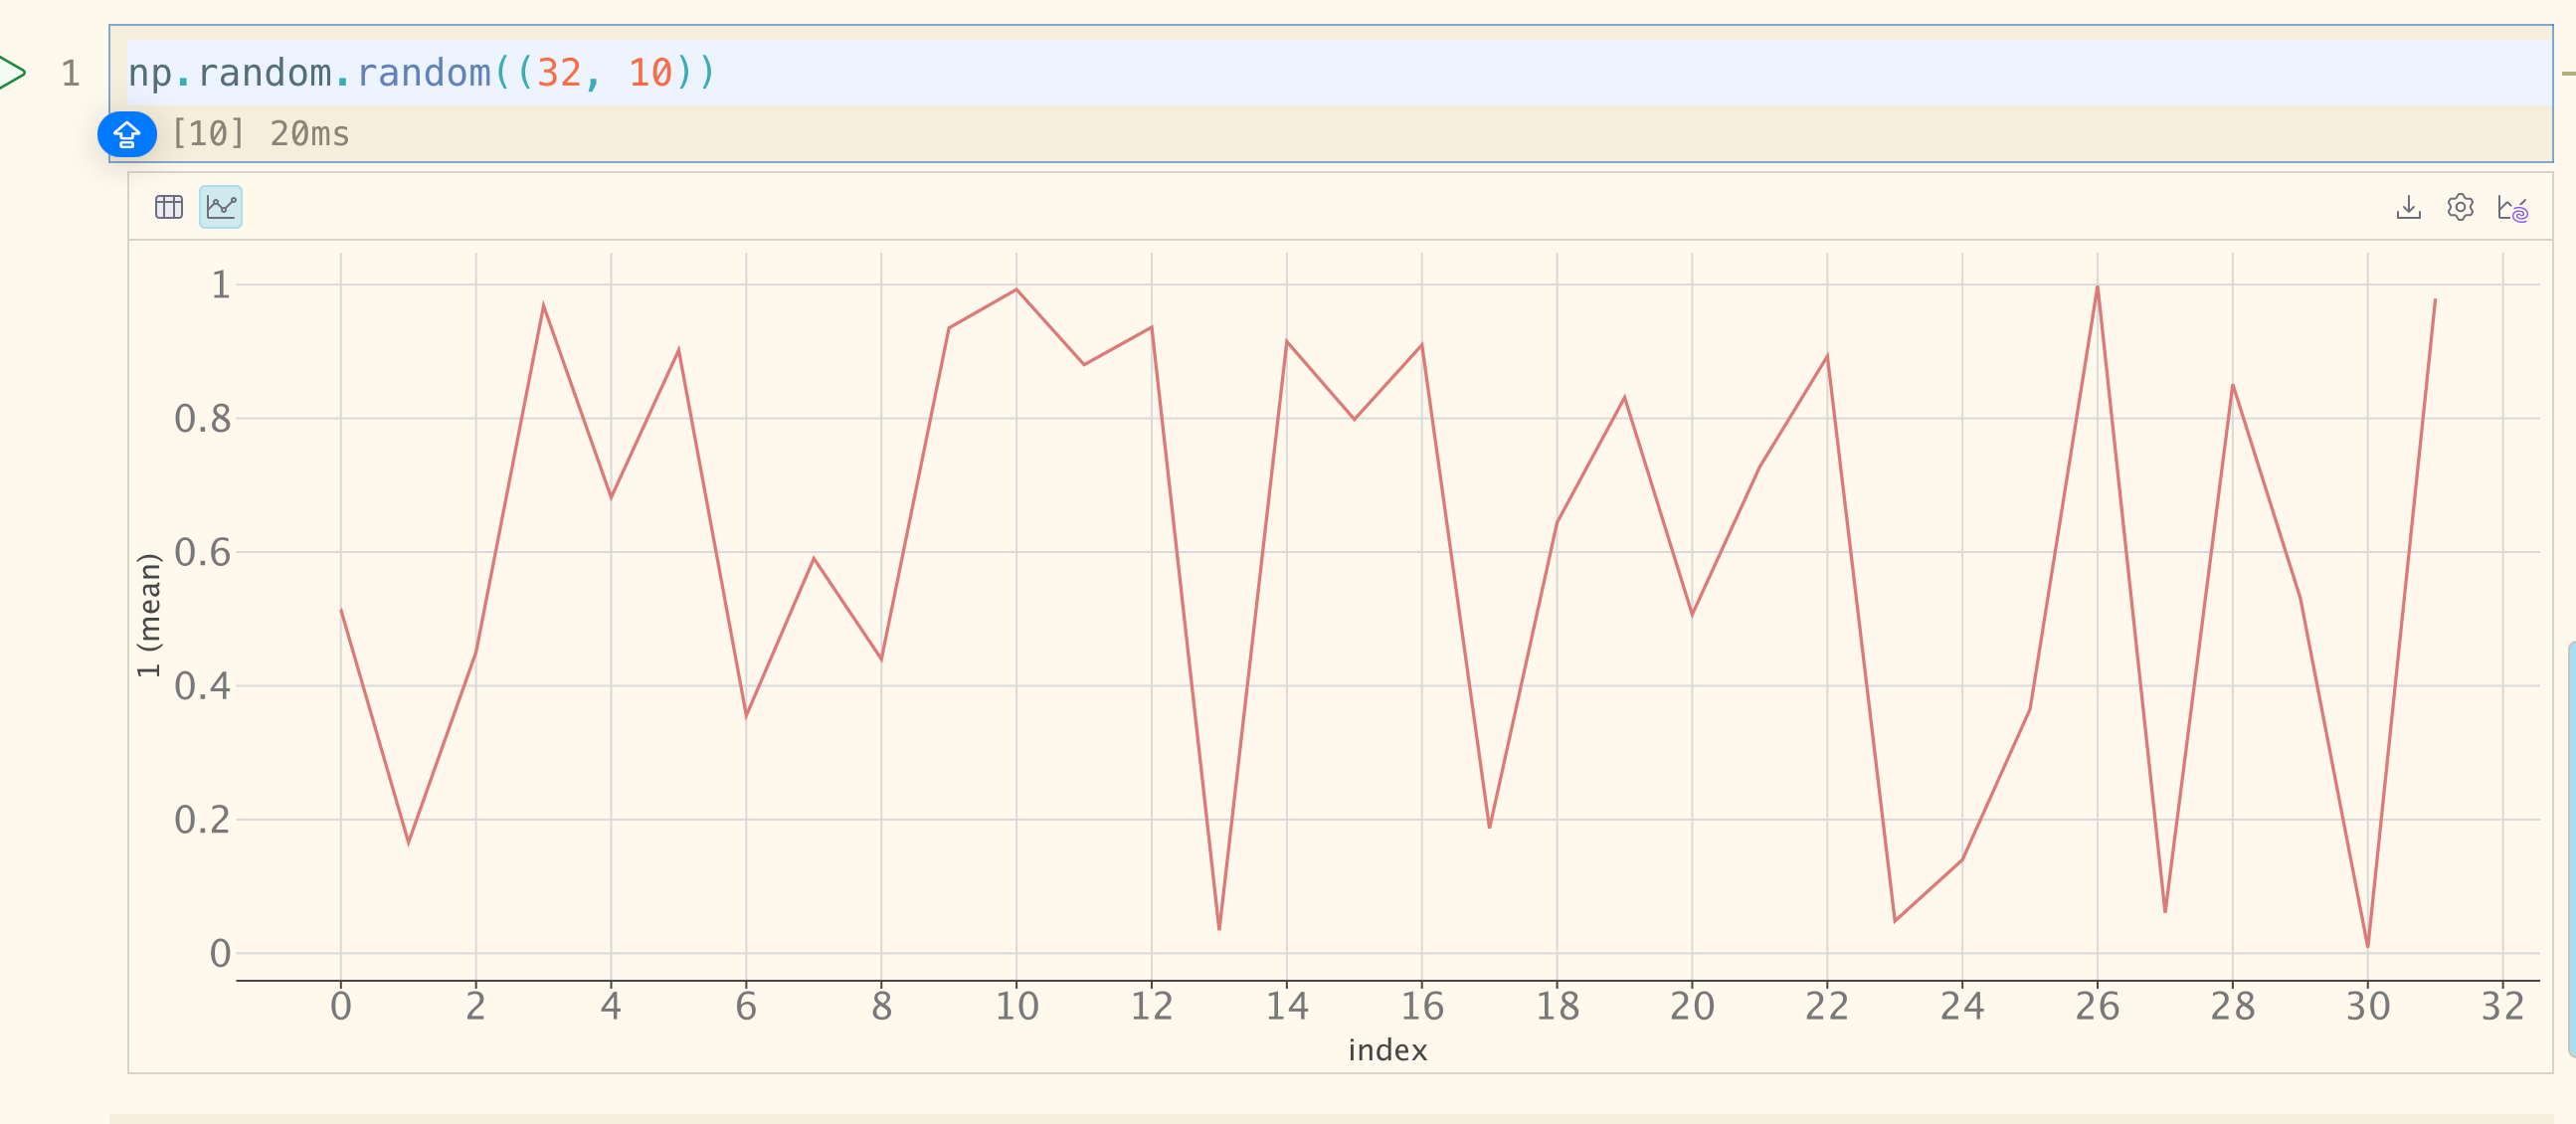

In [28]:
# rank-3 tensor (matrix)
x = np.random.random((32, 10))
# rank-2 tensor (vector)
y = np.random.random((10,))

In [29]:
y = np.expand_dims(y, axis=0)  # adding empty axis [] to y
y = np.tile(y, (32, 1)) # fills the axis [] with repeated data

### Tensor dot product
<br> When we have neurons conencted: <br> _linear -> linear -> linear -> ...._ and within a single linear cross product is executing ```(Wx + b)``` where:
<br> ```W``` = weight
<br> ```x``` = input
<br> ```b``` = bias
<br> _Wx_ is where cross product is occuring _W . x_

<br> _e.g._ **two 2-rank** tensors _(2, 3)_ and _(3, 2)_:
<br>
```
A = [[1, 2, 3],          # shape (2, 3)
     [4, 5, 6]]

B = [[7,  8],            # shape (3, 2)
     [9,  10],
     [11, 12]]
```
```
(2, 3) · (3, 2)
    │    │
    └────┘  inner: 3 == 3 ✅  valid, they cancel
 │        │
 └────────┘  outer: 2 and 2 → result (2, 2)```

```A · B = [[ 58,  64],     # shape (2, 2) ✅
         [139, 154]]```

### Reshaping tensors
<br> Changing the rank/shape of a tensor whilst keeping the same values.
<br><br> _e.g._ changing batch of images ```(60000, 28, 28)``` to ```(60000, 28*28)```. In other words we reshaped a **rank-3 (matrice) into a rank-2 (vector)**

In [30]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
print(x)

[[0. 1.]
 [2. 3.]
 [4. 5.]]


In [31]:
x = x.reshape((6, 1))
print(x)

[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]]


In [32]:
x = x.reshape(2, 3)
print(x)

[[0. 1. 2.]
 [3. 4. 5.]]


784 pixels  →  Dense(512) + ReLU  →  512 values
 input                                 (hidden representation)

## Geometric intepretation of tensor operations

<br> 1. **Translation** = Tensor addition
<br> 2. **Rotation** = Tensor product AND Rotation matrix
<br> 3. **Scaling** = Tensor product AND Scalar matrix

### Translation
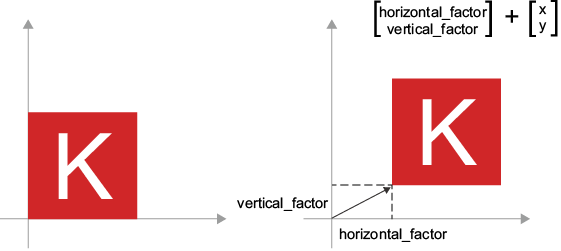
<br>When performing tensor addition we are moving (translating) a point from **one location to another.**

### Rotation
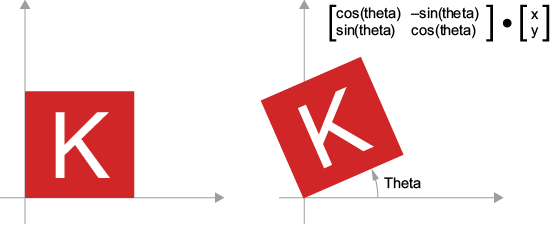
<br>Performing tensor product on a point with the rotation matrix will rotate them. <br> Rotation matrix = ```[cos(theta) -sin(theta), sin(theta) cos(theta)]```

### Scaling
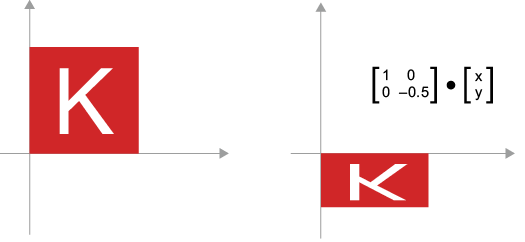
<br> Performing dot product on a point with a scaling matrix will rotate it.

### Linear & Affine Transform
_Linear transform_ = Wx     (**must pass through origin** (0, 0)
<br> _Affine transform_ = Wx + b    linear transform + translation (**can sit anywhere** on graph)
<br><br> **a Dense layer is an affine transform if it does not use an activation f(n)**

### How does it relate to neural networks?
We have ```Wx + b```:  <br>```Wx``` represents the following linear geometric operations = **scale, rotate**
<br> ```+ b``` represents the following linear geometric operations = **translate**
<br><br> Activation functions allow for **bending** (non-linearity)- if we only had affine transformation layers we would end up with only a affine transformation which gain nothing with depth thats why we need activations.

**Best way to understand:** unscrunching a piece of paper to read the information -> each layer un-crumples the data's space a little, until classes are cleanly seperable (readable) at the final layer.